In [1]:
%pip install regex typing_extensions safetensors tokenizers huggingface_hub

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install tokenizers==0.23.0

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following yanked versions: 0.12.0, 0.20.4
ERROR: Could not find a version that satisfies the requirement tokenizers==0.23.0 (from versions: 0.0.2, 0.0.3, 0.0.4, 0.0.5, 0.0.6, 0.0.7, 0.0.8, 0.0.9, 0.0.10, 0.0.11, 0.0.12, 0.0.13, 0.1.0, 0.1.1, 0.2.0, 0.2.1, 0.3.0, 0.4.0, 0.4.1, 0.4.2, 0.5.0, 0.5.1, 0.5.2, 0.6.0, 0.7.0rc4, 0.7.0rc5, 0.7.0rc6, 0.7.0rc7, 0.7.0, 0.8.0.dev0, 0.8.0.dev1, 0.8.0.dev2, 0.8.0rc1, 0.8.0rc2, 0.8.0rc3, 0.8.0rc4, 0.8.0, 0.8.1rc1, 0.8.1rc2, 0.8.1, 0.9.0.dev0, 0.9.0.dev1, 0.9.0.dev2, 0.9.0.dev3, 0.9.0.dev4, 0.9.0rc1, 0.9.0rc2, 0.9.0, 0.9.1, 0.9.2, 0.9.3, 0.9.4, 0.10.0rc1, 0.10.0, 0.10.1, 0.10.2, 0.10.3, 0.11.0, 0.11.1, 0.11.2, 0.11.3, 0.11.4, 0.11.5, 0.11.6, 0.12.1, 0.13.0, 0.13.1, 0.13.2, 0.13.3, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.15.2, 0.19.0, 0.19.1, 0.20.0, 0.20.1, 0.20.2, 0.20.3, 0.20.4rc0, 0.21.0rc0, 0.21.0, 0.21.1rc0, 0.21.1, 0.21.2rc0, 0.21.2, 0.21.4, 0.22.0, 0.22.1rc0, 0.22.1, 0.22.2rc0, 0.22.2, 0.23.0rc0, 0.23.1rc0, 0.23.1)

[notice] A new re

In [3]:
%pip install --upgrade transformers

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import transformers
import torch
from PIL import Image

print("CLIP environment is ready")

C:\Users\Captain\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CLIP environment is ready


In [5]:
from transformers import CLIPProcessor, CLIPModel
import torch

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("CLIP model loaded")

Loading weights: 100%|████████████████████████████████████████████████████████████| 398/398 [00:00<00:00, 19207.16it/s]


CLIP model loaded


In [6]:
import os
from PIL import Image
import numpy as np

def clip_vectorise(folder_path, dataset_name, max_images=250):
    embeddings = []
    names = []

    files = [f for f in os.listdir(folder_path) if f.endswith(".jpg")]
    files = files[:max_images]

    for i, file in enumerate(files):
        path = os.path.join(folder_path, file)

        try:
            image = Image.open(path).convert("RGB")

            inputs = processor(images=image, return_tensors="pt")

            with torch.no_grad():
                features = model.get_image_features(**inputs)

            vector = features[0].numpy()

            embeddings.append(vector)
            names.append(file)

            if (i+1) % 25 == 0:
                print(dataset_name, "processed:", i+1)

        except Exception as e:
            print("Skipped:", file)

    return np.array(embeddings), names

In [7]:
path1 = "../datasets/urban_architecture_facade_images"
path2 = "../datasets/loremflickr_city_street_images"

vec1, names1 = clip_vectorise(path1, "architecture")
vec2, names2 = clip_vectorise(path2, "street")

print("Architecture vectors:", vec1.shape)
print("Street vectors:", vec2.shape)

architecture processed: 25
architecture processed: 50
architecture processed: 75
architecture processed: 100
architecture processed: 125
architecture processed: 150
architecture processed: 175
architecture processed: 200
architecture processed: 225
architecture processed: 250
street processed: 25
street processed: 50
street processed: 75
street processed: 100
street processed: 125
street processed: 150
street processed: 175
street processed: 200
street processed: 225
street processed: 250
Architecture vectors: (250, 1, 50, 768)
Street vectors: (250, 1, 50, 768)


In [8]:
vec1 = vec1.reshape(250, -1)
vec2 = vec2.reshape(250, -1)

print(vec1.shape)
print(vec2.shape)

(250, 38400)
(250, 38400)


In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

vec1_2d = pca.fit_transform(vec1)
vec2_2d = pca.fit_transform(vec2)

In [10]:
%pip install scikit-learn

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from sklearn.decomposition import PCA

In [12]:
pca = PCA(n_components=2)

vec1_2d = pca.fit_transform(vec1)
vec2_2d = pca.fit_transform(vec2)

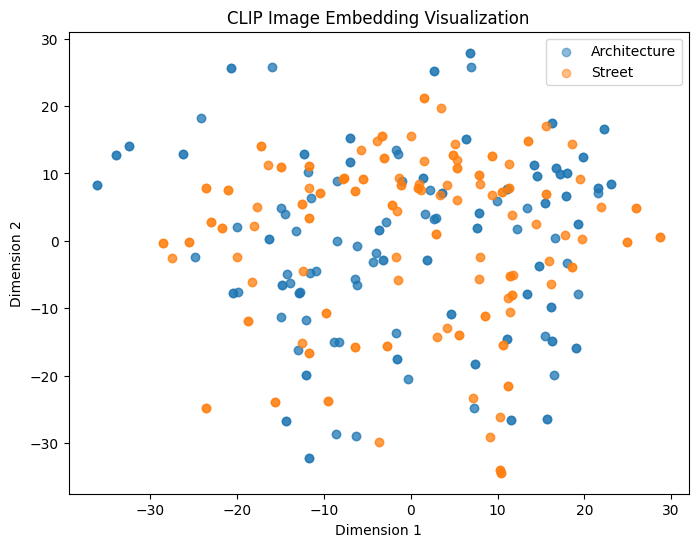

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(vec1_2d[:,0], vec1_2d[:,1], label="Architecture", alpha=0.5)
plt.scatter(vec2_2d[:,0], vec2_2d[:,1], label="Street", alpha=0.5)

plt.legend()
plt.title("CLIP Image Embedding Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()

In [14]:
%pip install matplotlib

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.comNote: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
plt.savefig("clip_visualisation.png")

<Figure size 640x480 with 0 Axes>

In [16]:
%pip install torchvision

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from torchvision import models
import torch

resnet = models.resnet50(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()

print("ResNet loaded successfully")

C:\Users\Captain\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Captain\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Captain/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:03<00:00, 31.3MB/s]


ResNet loaded successfully


In [18]:
from torchvision import transforms
from PIL import Image
import os
import numpy as np

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [19]:
def resnet_vectorise(folder_path, dataset_name):
    embeddings = []
    names = []

    for i, file in enumerate(os.listdir(folder_path)):
        try:
            path = os.path.join(folder_path, file)
            img = Image.open(path).convert("RGB")
            img = transform(img).unsqueeze(0)

            with torch.no_grad():
                feature = resnet(img)
                feature = feature.view(-1).numpy()

            embeddings.append(feature)
            names.append(file)

            if (i+1) % 25 == 0:
                print(dataset_name, "processed:", i+1)

        except:
            print("Skipped:", file)

    return np.array(embeddings), names

In [20]:
path1 = "../datasets/urban_architecture_facade_images"
path2 = "../datasets/loremflickr_city_street_images"

res_vec1, _ = resnet_vectorise(path1, "architecture_resnet")
res_vec2, _ = resnet_vectorise(path2, "street_resnet")

print(res_vec1.shape)
print(res_vec2.shape)

architecture_resnet processed: 25
architecture_resnet processed: 50
architecture_resnet processed: 75
architecture_resnet processed: 100
architecture_resnet processed: 125
architecture_resnet processed: 150
architecture_resnet processed: 175
architecture_resnet processed: 200
architecture_resnet processed: 225
architecture_resnet processed: 250
street_resnet processed: 25
street_resnet processed: 50
street_resnet processed: 75
street_resnet processed: 100
street_resnet processed: 125
street_resnet processed: 150
street_resnet processed: 175
street_resnet processed: 200
street_resnet processed: 225
street_resnet processed: 250
(250, 2048)
(250, 2048)


In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

res_vec1_2d = pca.fit_transform(res_vec1)
res_vec2_2d = pca.fit_transform(res_vec2)

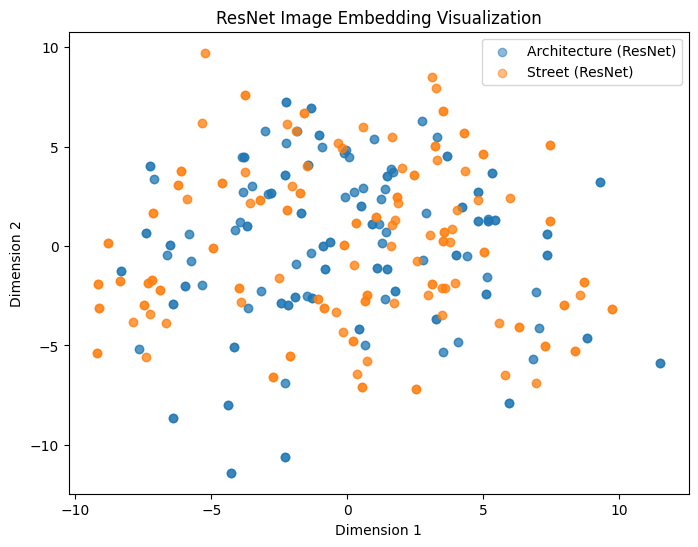

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(res_vec1_2d[:,0], res_vec1_2d[:,1], label="Architecture (ResNet)", alpha=0.5)
plt.scatter(res_vec2_2d[:,0], res_vec2_2d[:,1], label="Street (ResNet)", alpha=0.5)

plt.legend()
plt.title("ResNet Image Embedding Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()